In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import shapiro
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from scipy.stats import levene
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.stats.diagnostic import acorr_ljungbox

In [2]:
# Loading the data
df = pd.read_excel('output_week.xlsx')

# Count values and sort by week
data = df['WEEK'].value_counts().reset_index()
data.columns = ['WEEK', 'DATA']

# Convert week to a date representing the start of the week
data['WEEK_period'] = pd.to_datetime(data['WEEK'] + '-1', format='%G-%V-%u', errors='coerce')

data = data.sort_values('WEEK_period').reset_index(drop=True)

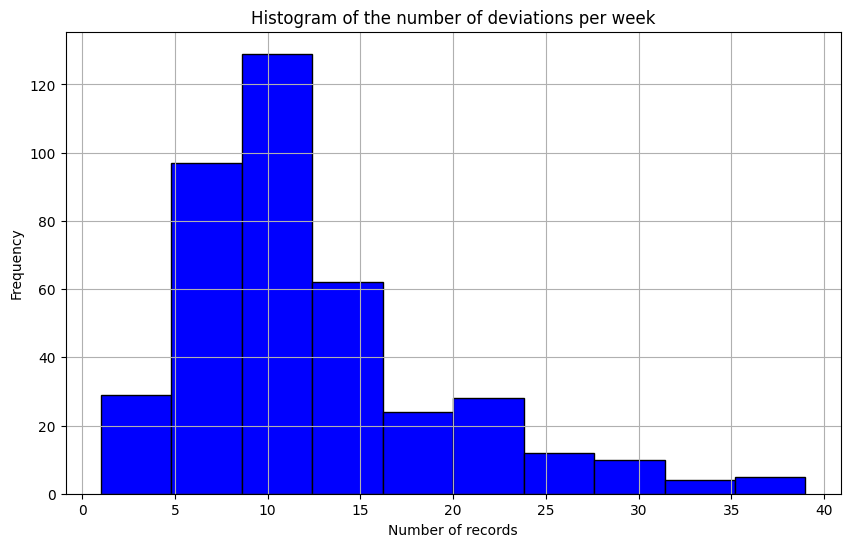

  Statistic  Value
0     count  400.0
1      mean   12.3
2       std    7.0
3       min    1.0
4       25%    7.0
5       50%   10.0
6       75%   15.0
7       max   39.0
Test statistic: 0.8943731690284691
p-value: 5.339482385277547e-16
The data does NOT follow a normal distribution (reject H0)
Skewness coefficient: 1.3497


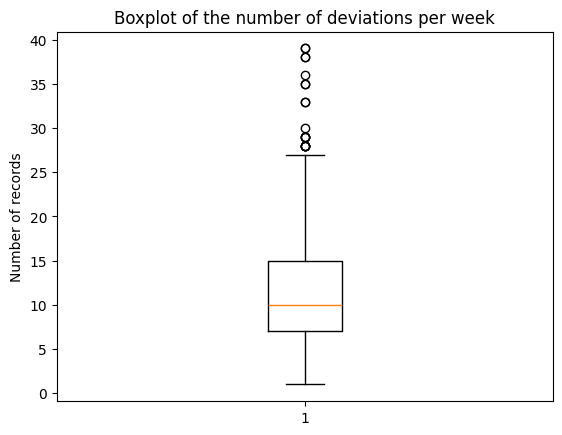

In [3]:
# Histogram of the data
plt.figure(figsize=(10, 6))
plt.hist(data['DATA'], bins=10, color='blue', edgecolor='black')
plt.title('Histogram of the number of deviations per week')
plt.xlabel('Number of records')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# Descriptive statistics
estat = data['DATA'].describe().round(2)

# Convert to DataFrame
estat_df = estat.to_frame().reset_index()

# Rename columns to more descriptive names
estat_df.columns = ['Statistic', 'Value']

print(estat_df)

# Normality test of the data
stat, p_value = shapiro(data['DATA'])

print(f'Test statistic: {stat}')
print(f'p-value: {p_value}')

if p_value > 0.05:
    print('The data appears to follow a normal distribution (fail to reject H0)')
else:
    print('The data does NOT follow a normal distribution (reject H0)')

# Skewness test
skewness = data['DATA'].skew()
print(f"Skewness coefficient: {skewness:.4f}")

# Boxplot
plt.boxplot(data['DATA'])
plt.title('Boxplot of the number of deviations per week')
plt.ylabel('Number of records')
plt.show()

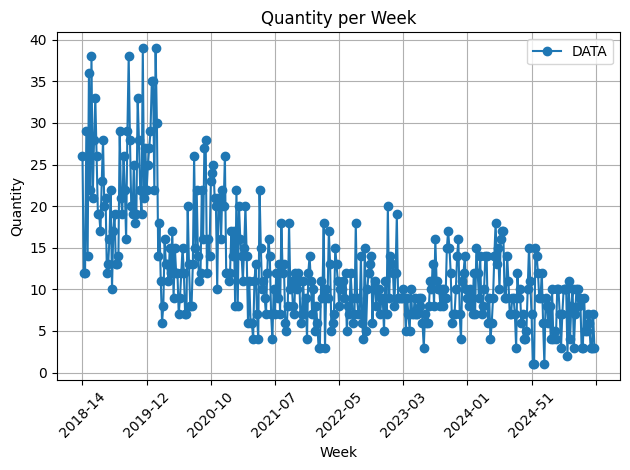


	---------------------------------------------------------
	Stationarity Test - Augmented Dickey-Fuller (ADF)
	---------------------------------------------------------
H0: The process is non-stationary.
H1: The process is stationary.

ADF Statistic: -2.458524222580615
p-value: 0.1258946361594218
Critical Values:
	Alpha	Critical Value	Result
	1%	-3.447405233596701	Fail to reject H0
	5%	-2.8690569369014605	Fail to reject H0
	10%	-2.5707743450830893	Fail to reject H0

	---------------------------------------------------------
	Homoscedasticity Test - Levene
	---------------------------------------------------------
H0: The variances of the sub-samples are equal (homoscedastic series).
H1: The variances of the sub-samples are different (heteroscedastic series).

Test statistic: 22.432084785799468
p-value: 1.0392215140692649e-16
Result: Reject H0


/Users/octaciliofsilvajunior/miniforge3/lib/python3.10/site-packages/numpy/core/fromnumeric.py:59: FutureWarning: 'Series.swapaxes' is deprecated and will be removed in a future version. Please use 'Series.transpose' instead.
  return bound(*args, **kwds)


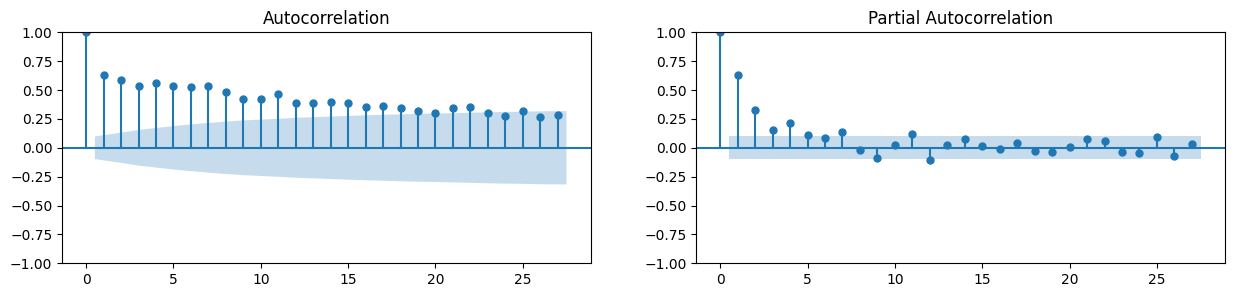

In [4]:
# Line plot
data.plot(x='WEEK', y='DATA', kind='line', marker='o', title='Quantity per Week')
plt.xlabel('Week')
plt.ylabel('Quantity')
plt.xticks(rotation=45)  # rotation of x-axis labels
plt.grid(True)
plt.tight_layout()       # adjusts layout to avoid cutting labels
plt.show()

# Autocorrelation and partial autocorrelation analysis
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15,3))

plot_acf(data['DATA'], lags=27, ax=ax[0])
plot_pacf(data['DATA'], lags=27, ax=ax[1])

# Augmented Dickey-Fuller stationarity test
def ADF(X):
  print("\n\t---------------------------------------------------------")
  print("\tStationarity Test - Augmented Dickey-Fuller (ADF)")
  print("\t---------------------------------------------------------")
  print("H0: The process is non-stationary.")
  print("H1: The process is stationary.")
  result = adfuller(X)
  print('\nADF Statistic: {}'.format(result[0]))
  print('p-value: {}'.format(result[1]))
  print('Critical Values:')
  print('\tAlpha\tCritical Value\tResult')
  for key, value in result[4].items():
    h0 = "Fail to reject H0" if result[0] > value else "Reject H0"
    print('\t{}\t{}\t{}'.format(key, value, h0))

ADF(data['DATA'])

# Levene homoscedasticity test
def Levene(X):
  print("\n\t---------------------------------------------------------")
  print("\tHomoscedasticity Test - Levene")
  print("\t---------------------------------------------------------")
  print("H0: The variances of the sub-samples are equal (homoscedastic series).")
  print("H1: The variances of the sub-samples are different (heteroscedastic series).")
  janelas = np.array_split(X, 5)
  resultado = levene(*janelas)
  print("\nTest statistic: {}".format(resultado.statistic))
  print("p-value: {}".format(resultado.pvalue))
  print("Result: {}".format('Fail to reject H0' if resultado.pvalue > 0.05 else 'Reject H0'))

Levene(data['DATA'])

Original variance: 48.98944862155391
Log variance: 0.33598021231064573
It is likely a multiplicative model.


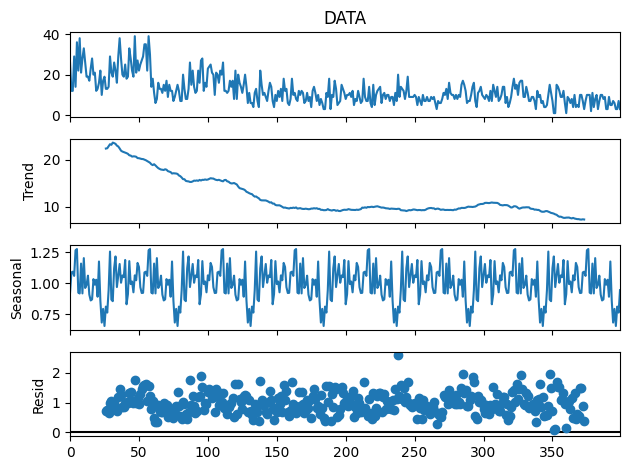

In [5]:
# Check whether the time series is additive or multiplicative

# Compare original variance vs log-transformed variance
var_original = data['DATA'].var()
var_log = np.log(data['DATA']).var()

print("Original variance:", var_original)
print("Log variance:", var_log)

if var_log < var_original * 0.5:
    print("It is likely a multiplicative model.")
else:
    print("It is likely an additive model.")

result = seasonal_decompose(data['DATA'], model='multiplicative', period=53)

result.plot()
plt.show()

In [6]:
# Ljung-Box test for significant autocorrelations
def LjungBox(X, lags=12):
    print("\n\t---------------------------------------------------------")
    print("\tAutocorrelation Test - Ljung-Box")
    print("\t---------------------------------------------------------")
    print("H0: The lag has no autocorrelation (it is IID).")
    print("H1: The lag has autocorrelation.")
    
    result = acorr_ljungbox(X, lags=lags)  # returns a DataFrame

    for i in range(len(result)):
        stat = result['lb_stat'].iloc[i]
        pval = result['lb_pvalue'].iloc[i]
        print(f"LAG {i+1}")
        print(f"\tTest statistic: {stat:.4f}")
        print(f"\tp-value: {pval:.4f}")
        print(f"\tResult: {'H0 Accepted' if pval > 0.05 else 'H0 Rejected'}")

LjungBox(data['DATA'], lags=27)


	---------------------------------------------------------
	Autocorrelation Test - Ljung-Box
	---------------------------------------------------------
H0: The lag has no autocorrelation (it is IID).
H1: The lag has autocorrelation.
LAG 1
	Test statistic: 158.4697
	p-value: 0.0000
	Result: H0 Rejected
LAG 2
	Test statistic: 299.1091
	p-value: 0.0000
	Result: H0 Rejected
LAG 3
	Test statistic: 414.8910
	p-value: 0.0000
	Result: H0 Rejected
LAG 4
	Test statistic: 543.7932
	p-value: 0.0000
	Result: H0 Rejected
LAG 5
	Test statistic: 660.6749
	p-value: 0.0000
	Result: H0 Rejected
LAG 6
	Test statistic: 772.5600
	p-value: 0.0000
	Result: H0 Rejected
LAG 7
	Test statistic: 891.1727
	p-value: 0.0000
	Result: H0 Rejected
LAG 8
	Test statistic: 985.3328
	p-value: 0.0000
	Result: H0 Rejected
LAG 9
	Test statistic: 1057.9859
	p-value: 0.0000
	Result: H0 Rejected
LAG 10
	Test statistic: 1132.0547
	p-value: 0.0000
	Result: H0 Rejected
LAG 11
	Test statistic: 1223.1963
	p-value: 0.0000
	Result: H0 


	---------------------------------------------------------
	Stationarity Test - Augmented Dickey-Fuller (ADF)
	---------------------------------------------------------
H0: The process is non-stationary.
H1: The process is stationary.

ADF Statistic: -7.631919125961659
p-value: 1.998369680182694e-11
Critical Values:
	Alpha	Critical Value	Result
	1%	-3.447405233596701	Reject H0
	5%	-2.8690569369014605	Reject H0
	10%	-2.5707743450830893	Reject H0

	---------------------------------------------------------
	Stationarity Test - Augmented Dickey-Fuller (ADF)
	---------------------------------------------------------
H0: The process is non-stationary.
H1: The process is stationary.

ADF Statistic: -9.929575257425583
p-value: 2.8465033853820613e-17
Critical Values:
	Alpha	Critical Value	Result
	1%	-3.4476305904172904	Reject H0
	5%	-2.869155980820355	Reject H0
	10%	-2.570827146203181	Reject H0


/var/folders/36/lb3mdhtj2lldbybnz877q_hr0000gn/T/ipykernel_5836/1007662680.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data1['diff_2'] = data['DATA'].diff().diff()


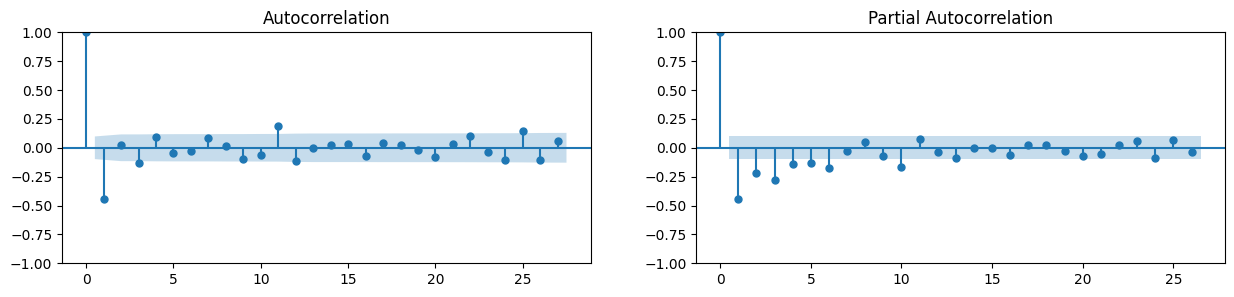

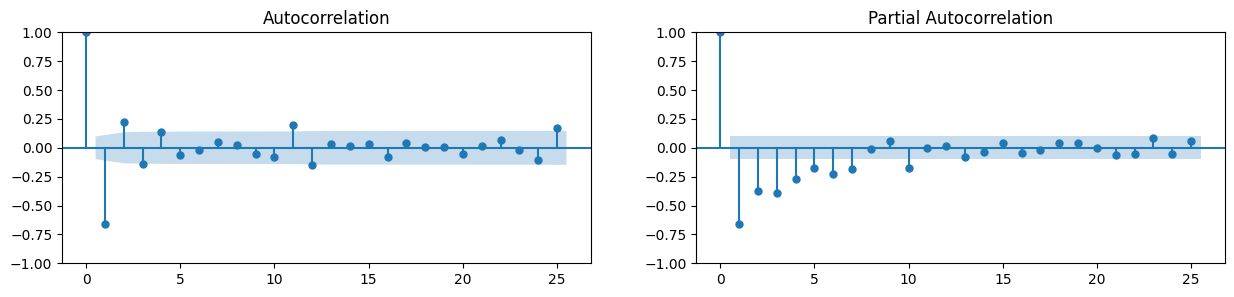

In [7]:
# Transform the data by applying first-order differencing
data['diff_1'] = data['DATA'].diff()

# Remove NaN values resulting from the first observation
data1 = data.dropna(subset=['diff_1'])

# Autocorrelation and partial autocorrelation analysis
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15,3))

plot_acf(data1['diff_1'], lags=27, ax=ax[0])
plot_pacf(data1['diff_1'], lags=26, ax=ax[1])

ADF(data1['diff_1'])

# Transform the data by applying second-order differencing
data1['diff_2'] = data['DATA'].diff().diff()

# Remove NaN values resulting from differencing
data2 = data1.dropna(subset=['diff_2'])

# Autocorrelation and partial autocorrelation analysis
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15,3))

plot_acf(data2['diff_2'], lags=25, ax=ax[0])
plot_pacf(data2['diff_2'], lags=25, ax=ax[1])

ADF(data2['diff_2'])

In [8]:
# Ljung-Box test for significant autocorrelations
def LjungBox(X, lags=12):
    print("\n\t---------------------------------------------------------")
    print("\tAutocorrelation Test - Ljung-Box")
    print("\t---------------------------------------------------------")
    print("H0: The lag has no autocorrelation (it is IID).")
    print("H1: The lag has autocorrelation.")
    
    result = acorr_ljungbox(X, lags=lags)  # returns a DataFrame

    for i in range(len(result)):
        stat = result['lb_stat'].iloc[i]
        pval = result['lb_pvalue'].iloc[i]
        print(f"LAG {i+1}")
        print(f"\tTest statistic: {stat:.4f}")
        print(f"\tp-value: {pval:.4f}")
        print(f"\tResult: {'H0 Accepted' if pval > 0.05 else 'H0 Rejected'}")

LjungBox(data1['diff_1'], lags=27)


	---------------------------------------------------------
	Autocorrelation Test - Ljung-Box
	---------------------------------------------------------
H0: The lag has no autocorrelation (it is IID).
H1: The lag has autocorrelation.
LAG 1
	Test statistic: 78.8877
	p-value: 0.0000
	Result: H0 Rejected
LAG 2
	Test statistic: 79.0887
	p-value: 0.0000
	Result: H0 Rejected
LAG 3
	Test statistic: 86.0575
	p-value: 0.0000
	Result: H0 Rejected
LAG 4
	Test statistic: 89.5834
	p-value: 0.0000
	Result: H0 Rejected
LAG 5
	Test statistic: 90.2830
	p-value: 0.0000
	Result: H0 Rejected
LAG 6
	Test statistic: 90.5366
	p-value: 0.0000
	Result: H0 Rejected
LAG 7
	Test statistic: 93.5454
	p-value: 0.0000
	Result: H0 Rejected
LAG 8
	Test statistic: 93.6798
	p-value: 0.0000
	Result: H0 Rejected
LAG 9
	Test statistic: 97.4515
	p-value: 0.0000
	Result: H0 Rejected
LAG 10
	Test statistic: 99.0610
	p-value: 0.0000
	Result: H0 Rejected
LAG 11
	Test statistic: 113.8085
	p-value: 0.0000
	Result: H0 Rejected
LAG 